# Bluestock Mutual Fund Analytics

## 05 - Advanced Analytics

This notebook performs advanced analysis for the mutual fund dataset.

The analysis includes:

1. Historical Value at Risk (VaR)
2. Investor cohort analysis
3. Rule-based mutual fund recommendation logic

The objective is to estimate downside risk, understand investor behaviour
over time, and create an explainable recommendation framework.

In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed folder:", PROCESSED_DIR)
print("Exists:", PROCESSED_DIR.exists())

Processed folder: c:\Users\Farhan\bluestock_mf_capstone\data\processed
Exists: True


In [46]:
def find_dataset(keyword):
    files = list(PROCESSED_DIR.glob(f"*{keyword}*.csv"))

    if not files:
        raise FileNotFoundError(
            f"Dataset not found for: {keyword}"
        )

    return files[0]


nav_file = find_dataset("nav_history")
fund_file = find_dataset("fund_master")
performance_file = find_dataset("scheme_performance")
transactions_file = find_dataset("investor_transactions")

nav = pd.read_csv(nav_file)
funds = pd.read_csv(fund_file)
performance = pd.read_csv(performance_file)
transactions = pd.read_csv(transactions_file)

print("NAV:", nav.shape)
print("Fund Master:", funds.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)

NAV: (46000, 3)
Fund Master: (40, 15)
Performance: (40, 19)
Transactions: (32778, 13)


In [47]:
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav["amfi_code"] = pd.to_numeric(
    nav["amfi_code"],
    errors="coerce"
)

nav = nav.dropna(
    subset=["amfi_code", "date", "nav"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav_returns = nav.dropna(
    subset=["daily_return"]
).copy()

print("NAV return observations:", len(nav_returns))

display(nav_returns.head())

NAV return observations: 45960


,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [48]:
var_results = []

for amfi_code, group in nav_returns.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_quantile = returns.quantile(0.05)

    historical_var_95 = -var_quantile * 100

    var_results.append({
        "amfi_code": int(amfi_code),
        "historical_var_95_daily_pct": historical_var_95
    })


var_df = pd.DataFrame(var_results)

var_df = var_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

var_df = var_df.sort_values(
    "historical_var_95_daily_pct",
    ascending=False
)

display(var_df.head(10))

,amfi_code,historical_var_95_daily_pct,scheme_name
22,119599,2.685944,SBI Small Cap Fund - Direct Plan - Growth
17,119095,2.618842,Axis Small Cap Fund - Regular - Growth
4,101207,2.602125,ABSL Small Cap Fund - Regular - Growth
11,118634,2.543811,Nippon India Small Cap Fund - Regular - Growth
21,119598,2.450705,SBI Small Cap Fund - Regular Plan - Growth
39,149324,2.348307,DSP Small Cap Fund - Regular - Growth
7,102886,1.922028,UTI Mid Cap Fund - Regular - Growth
2,100033,1.903354,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,1.889179,ICICI Pru Midcap Fund - Regular - Growth
16,119094,1.848028,Axis Midcap Fund - Regular - Growth


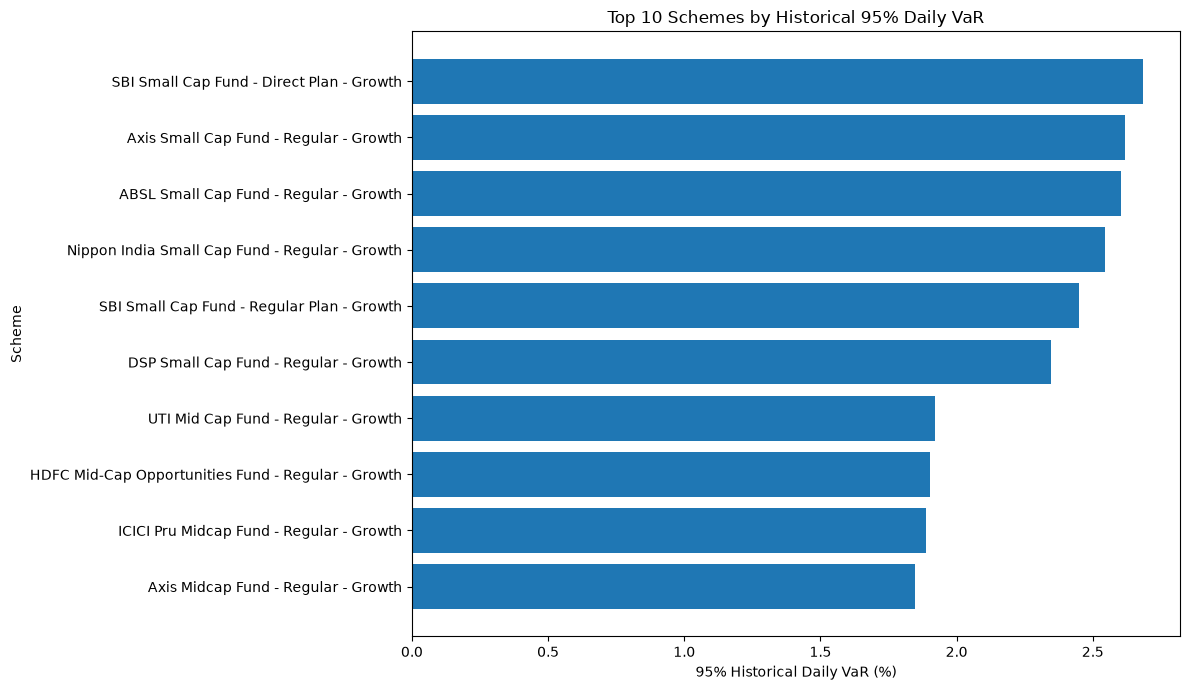

In [49]:
top_var = var_df.head(10).sort_values(
    "historical_var_95_daily_pct"
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_var["scheme_name"],
    top_var["historical_var_95_daily_pct"]
)

plt.xlabel("95% Historical Daily VaR (%)")
plt.ylabel("Scheme")
plt.title("Top 10 Schemes by Historical 95% Daily VaR")

plt.tight_layout()
plt.show()

## VaR Interpretation

Historical 95% daily VaR estimates the potential loss threshold associated
with the lower 5% of observed daily return outcomes.

A higher VaR value indicates greater historical downside exposure.

VaR is a risk measure rather than a prediction of the maximum possible loss.
Extreme market events can produce losses larger than the estimated VaR.

In [50]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

transactions = transactions.dropna(
    subset=["investor_id", "transaction_date"]
)

transactions["transaction_month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

print("Valid transactions:", len(transactions))
display(transactions.head())

Valid transactions: 32778


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01


In [51]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_month"]
    .min()
    .reset_index()
)

first_transaction.columns = [
    "investor_id",
    "cohort_month"
]

transactions = transactions.merge(
    first_transaction,
    on="investor_id",
    how="left"
)

print("Unique investors:", transactions["investor_id"].nunique())

display(
    transactions[
        [
            "investor_id",
            "transaction_month",
            "cohort_month"
        ]
    ].head(10)
)

Unique investors: 5000


,investor_id,transaction_month,cohort_month
0,INV003054,2024-01,2024-01
1,INV002952,2024-01,2024-01
2,INV003420,2024-01,2024-01
3,INV003436,2024-01,2024-01
4,INV004691,2024-01,2024-01
5,INV001497,2024-01,2024-01
6,INV000786,2024-01,2024-01
7,INV000616,2024-01,2024-01
8,INV003670,2024-01,2024-01
9,INV002054,2024-01,2024-01


In [52]:
cohort_activity = (
    transactions
    .groupby(
        ["cohort_month", "transaction_month"]
    )["investor_id"]
    .nunique()
    .reset_index(name="active_investors")
)

cohort_activity

,cohort_month,transaction_month,active_investors
0,2024-01,2024-01,1577
1,2024-01,2024-02,540
2,2024-01,2024-03,567
3,2024-01,2024-04,541
4,2024-01,2024-05,550
...,...,...,...
148,2025-03,2025-04,9
149,2025-03,2025-05,8
150,2025-04,2025-04,29
151,2025-04,2025-05,2


In [53]:
cohort_activity["cohort_month"] = (
    cohort_activity["cohort_month"].astype(str)
)

cohort_activity["transaction_month"] = (
    cohort_activity["transaction_month"].astype(str)
)

cohort_activity["cohort_date"] = pd.to_datetime(
    cohort_activity["cohort_month"]
)

cohort_activity["activity_date"] = pd.to_datetime(
    cohort_activity["transaction_month"]
)

cohort_activity["months_since_cohort"] = (
    (cohort_activity["activity_date"].dt.year -
     cohort_activity["cohort_date"].dt.year) * 12
    +
    (cohort_activity["activity_date"].dt.month -
     cohort_activity["cohort_date"].dt.month)
)

display(cohort_activity.head(10))

,cohort_month,transaction_month,active_investors,cohort_date,activity_date,months_since_cohort
0,2024-01,2024-01,1577,2024-01-01,2024-01-01,0
1,2024-01,2024-02,540,2024-01-01,2024-02-01,1
2,2024-01,2024-03,567,2024-01-01,2024-03-01,2
3,2024-01,2024-04,541,2024-01-01,2024-04-01,3
4,2024-01,2024-05,550,2024-01-01,2024-05-01,4
5,2024-01,2024-06,565,2024-01-01,2024-06-01,5
6,2024-01,2024-07,546,2024-01-01,2024-07-01,6
7,2024-01,2024-08,548,2024-01-01,2024-08-01,7
8,2024-01,2024-09,523,2024-01-01,2024-09-01,8
9,2024-01,2024-10,566,2024-01-01,2024-10-01,9


In [54]:
cohort_matrix = cohort_activity.pivot_table(
    index="cohort_month",
    columns="months_since_cohort",
    values="active_investors",
    aggfunc="sum"
)

display(cohort_matrix)

months_since_cohort,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
cohort_month,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0,NaN
2024-03,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0,NaN,NaN
2024-04,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0,NaN,NaN,NaN
2024-05,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0,NaN,NaN,NaN,NaN
2024-06,236.0,61.0,73.0,50.0,79.0,60.0,59.0,74.0,59.0,70.0,68.0,54.0,NaN,NaN,NaN,NaN,NaN
2024-07,175.0,45.0,40.0,41.0,43.0,36.0,40.0,36.0,41.0,38.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,135.0,24.0,32.0,30.0,31.0,29.0,34.0,34.0,23.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,17.0,19.0,22.0,21.0,20.0,13.0,19.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
cohort_retention = cohort_matrix.copy()

for cohort in cohort_retention.index:
    first_month_count = cohort_retention.loc[
        cohort, 0
    ]

    if pd.notna(first_month_count) and first_month_count > 0:
        cohort_retention.loc[cohort] = (
            cohort_retention.loc[cohort]
            / first_month_count
            * 100
        )

display(
    cohort_retention.round(1)
)

months_since_cohort,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
cohort_month,,,,,,,,,,,,,,,,,
2024-01,100.0,34.2,36.0,34.3,34.9,35.8,34.6,34.7,33.2,35.9,34.5,34.9,36.3,32.8,34.1,34.6,37.2
2024-02,100.0,36.0,37.1,35.6,35.6,35.4,37.9,34.5,31.8,35.2,35.2,35.8,31.9,35.1,32.2,32.7,NaN
2024-03,100.0,31.2,35.1,37.1,31.8,31.2,31.2,31.8,30.6,32.1,34.7,27.5,33.8,34.5,31.2,NaN,NaN
2024-04,100.0,27.2,31.1,31.5,29.0,31.5,34.0,29.0,29.9,31.7,29.3,31.1,30.6,31.7,NaN,NaN,NaN
2024-05,100.0,26.2,35.7,29.9,25.9,26.5,27.2,34.7,30.3,25.5,30.3,27.2,28.9,NaN,NaN,NaN,NaN
2024-06,100.0,25.8,30.9,21.2,33.5,25.4,25.0,31.4,25.0,29.7,28.8,22.9,NaN,NaN,NaN,NaN,NaN
2024-07,100.0,25.7,22.9,23.4,24.6,20.6,22.9,20.6,23.4,21.7,21.1,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.0,17.8,23.7,22.2,23.0,21.5,25.2,25.2,17.0,27.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,17.0,19.0,22.0,21.0,20.0,13.0,19.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# Find project processed folder automatically
from pathlib import Path

project_root = Path.cwd()

while project_root != project_root.parent and not (project_root / "data" / "processed").exists():
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"

# Save cohort retention CSV
cohort_retention_powerbi.to_csv(
    processed_dir / "cohort_retention.csv",
    index=False
)

print("Cohort retention CSV saved successfully!")
print(processed_dir / "cohort_retention.csv")

display(cohort_retention_powerbi.head(10))

Cohort retention CSV saved successfully!
c:\Users\Farhan\bluestock_mf_capstone\data\processed\cohort_retention.csv


,cohort_month,months_since_cohort,retention_pct
0,2024-01,0,100.0
1,2024-02,0,100.0
2,2024-03,0,100.0
3,2024-04,0,100.0
4,2024-05,0,100.0
5,2024-06,0,100.0
6,2024-07,0,100.0
7,2024-08,0,100.0
8,2024-09,0,100.0
9,2024-10,0,100.0


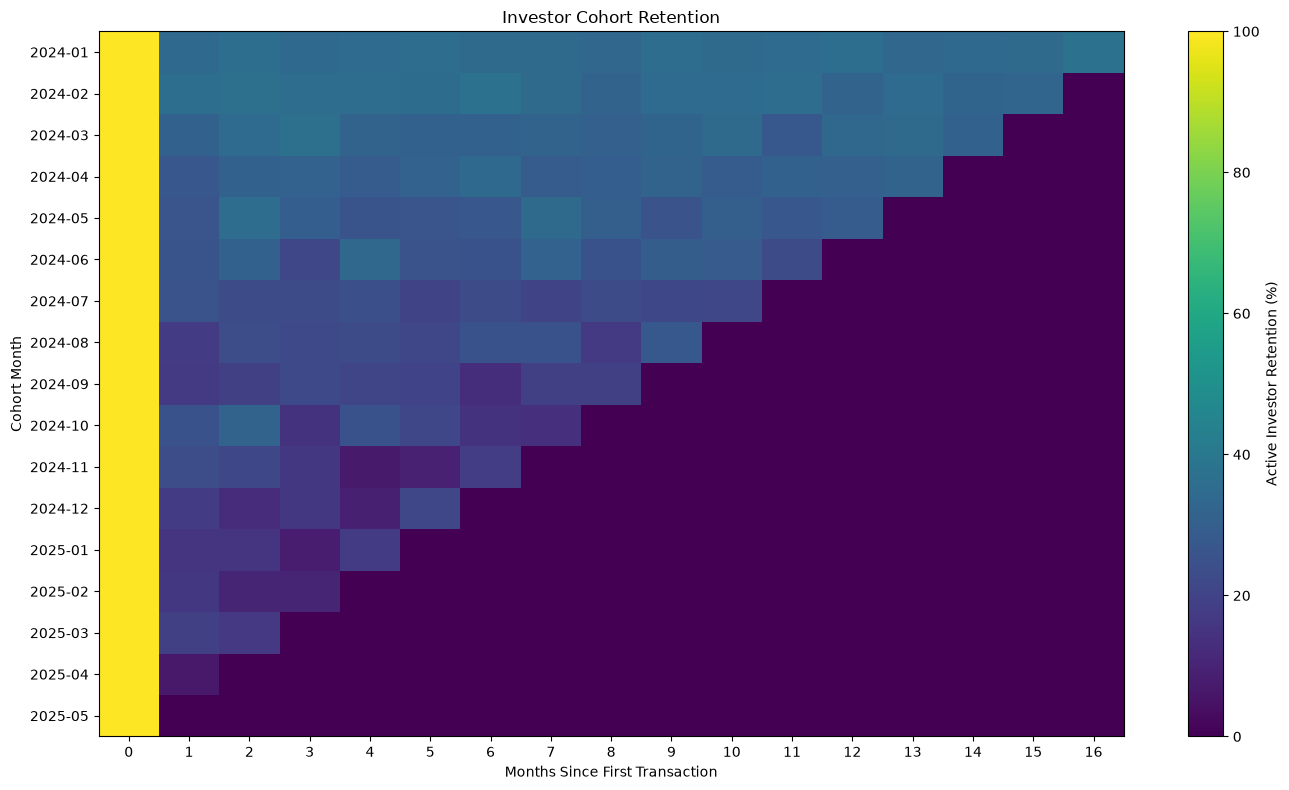

In [57]:
plt.figure(figsize=(14, 8))

plt.imshow(
    cohort_retention.fillna(0),
    aspect="auto"
)

plt.colorbar(
    label="Active Investor Retention (%)"
)

plt.xlabel("Months Since First Transaction")
plt.ylabel("Cohort Month")
plt.title("Investor Cohort Retention")

plt.xticks(
    range(len(cohort_retention.columns)),
    cohort_retention.columns
)

plt.yticks(
    range(len(cohort_retention.index)),
    cohort_retention.index
)

plt.tight_layout()
plt.show()

## Cohort Analysis Insights

Cohort analysis groups investors according to the month of their first
transaction and measures subsequent transaction activity.

This analysis helps identify whether investors who entered the mutual fund
ecosystem in different periods continued to remain active.

Higher retention percentages indicate stronger continued investor activity
relative to the cohort's first observed month.

The analysis is based on transaction activity and should not be interpreted
as a direct measure of investor profitability.

In [58]:
# =========================================================
# CELL 16 — MUTUAL FUND RECOMMENDATION SCORE
# =========================================================

recommendation_data = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "sharpe_ratio",
        "std_dev_ann_pct",
        "max_drawdown_pct",
        "expense_ratio_pct",
        "risk_grade"
    ]
].copy()


# ---------------------------------------------------------
# HANDLE NUMERIC COLUMNS
# ---------------------------------------------------------
numeric_columns = [
    "return_3yr_pct",
    "sharpe_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "expense_ratio_pct"
]

for col in numeric_columns:
    recommendation_data[col] = pd.to_numeric(
        recommendation_data[col],
        errors="coerce"
    )


# ---------------------------------------------------------
# RANK-BASED SCORES
# ---------------------------------------------------------

# Higher 3-year return = better
recommendation_data["return_score"] = (
    recommendation_data["return_3yr_pct"]
    .rank(pct=True)
)


# Higher Sharpe ratio = better
recommendation_data["sharpe_score"] = (
    recommendation_data["sharpe_ratio"]
    .rank(pct=True)
)


# Lower volatility = better
recommendation_data["volatility_score"] = (
    1
    - recommendation_data["std_dev_ann_pct"]
      .rank(pct=True)
)


# Smaller absolute drawdown = better
# Example:
# -17% drawdown is better than -33% drawdown
recommendation_data["drawdown_score"] = (
    1
    - recommendation_data["max_drawdown_pct"]
      .abs()
      .rank(pct=True)
)


# Lower expense ratio = better
recommendation_data["expense_score"] = (
    1
    - recommendation_data["expense_ratio_pct"]
      .rank(pct=True)
)


# ---------------------------------------------------------
# FINAL WEIGHTED SCORE
# ---------------------------------------------------------
recommendation_data["recommendation_score"] = (
    0.30 * recommendation_data["return_score"]
    + 0.25 * recommendation_data["sharpe_score"]
    + 0.20 * recommendation_data["volatility_score"]
    + 0.15 * recommendation_data["drawdown_score"]
    + 0.10 * recommendation_data["expense_score"]
)


# ---------------------------------------------------------
# SORT BEST TO WORST
# ---------------------------------------------------------
recommendation_data = recommendation_data.sort_values(
    "recommendation_score",
    ascending=False
).reset_index(drop=True)


# ---------------------------------------------------------
# DISPLAY TOP 10
# ---------------------------------------------------------
display(
    recommendation_data[
        [
            "scheme_name",
            "return_3yr_pct",
            "sharpe_ratio",
            "std_dev_ann_pct",
            "max_drawdown_pct",
            "expense_ratio_pct",
            "recommendation_score"
        ]
    ].head(10)
)

,scheme_name,return_3yr_pct,sharpe_ratio,std_dev_ann_pct,max_drawdown_pct,expense_ratio_pct,recommendation_score
0,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68,0.5,-2.62,0.74,0.706250
1,Kotak Liquid Fund - Regular - Growth,6.18,6.18,0.5,-3.81,0.60,0.687500
2,HDFC Short Term Debt Fund - Regular - Growth,7.37,1.84,4.0,-6.01,0.56,0.666250
3,Nippon India Gilt Securities Fund - Regular - ...,5.31,1.33,4.0,-2.23,0.55,0.652500
4,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.06,14.0,-17.07,1.46,0.648125
5,ABSL Liquid Fund - Regular - Growth,5.14,5.14,0.5,-3.66,0.79,0.642500
6,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.52,4.0,-2.30,0.77,0.642500
7,HDFC Top 100 Fund - Regular Plan - Growth,14.84,1.06,14.0,-17.41,1.55,0.625625
8,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,25.0,-13.35,1.43,0.623750
9,Nippon India Large Cap Fund - Regular - Growth,14.00,1.00,14.0,-16.07,1.51,0.606250


In [59]:
recommender_output = (
    PROCESSED_DIR /
    "fund_recommendations.csv"
)

recommendation_data.to_csv(
    recommender_output,
    index=False
)

print("Saved:", recommender_output)

Saved: c:\Users\Farhan\bluestock_mf_capstone\data\processed\fund_recommendations.csv


## Advanced Analytics Conclusion

The advanced analytics layer combines downside-risk analysis, investor cohort
analysis, and an explainable fund-ranking framework.

Historical VaR provides a downside-risk estimate based on observed returns.
Cohort analysis measures continued investor activity after the first
transaction month.

The recommender uses a transparent weighted scoring approach that combines
medium-term returns, risk-adjusted performance, volatility, drawdown, and
expense ratio.

The recommendation score is an analytical ranking and should not be treated
as personalised financial advice.